In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [9]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)
print(df.shape)
df.head()

(588101, 6)


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [14]:
#user_id=>重複なし
print(len(df["user id"]))
print(len(set(df["user id"])))
print(len(df["user id"].unique()))

588101
588101
588101


In [15]:
#test group(psaは広告と関係ない公共広告を見せたユーザー群)
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [23]:
#converted→最終的に広告経由で購入したか→全体の2.5% 

df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

<Axes: >

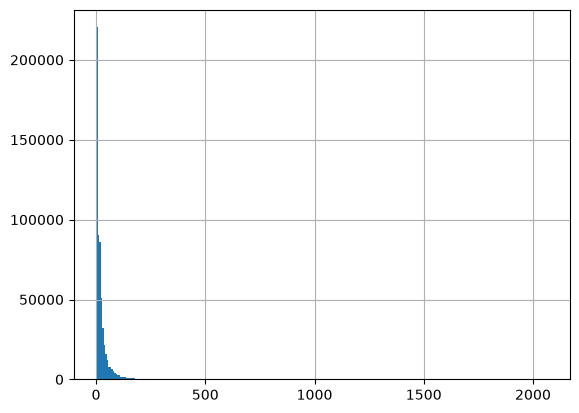

In [27]:
#total adsの数
df["total ads"].hist(bins=300)

In [29]:
#広告群とコンバージョン率の関係性
df.groupby("test group")["total ads"].describe().T

test group,ad,psa
count,564577.000000,23524.000000
mean,24.823365,24.761138
std,43.750456,42.860720
min,1.000000,1.000000
25%,4.000000,4.000000
50%,13.000000,12.000000
75%,27.000000,26.000000
max,2065.000000,907.000000


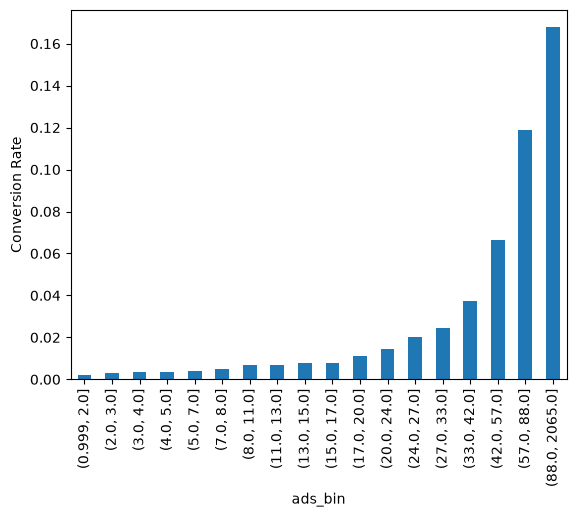

In [33]:
#広告数→見れば見るほどConversion Rateは上がりそう？
df["ads_bin"] = pd.qcut(df["total ads"], q=20, duplicates="drop")
df.groupby("ads_bin", observed =False)["converted"].mean().plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.show()

In [34]:
#広告有り無しでのConversion率の違い→ありそう
df.groupby("test group")["converted"].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

<Figure size 1200x600 with 0 Axes>

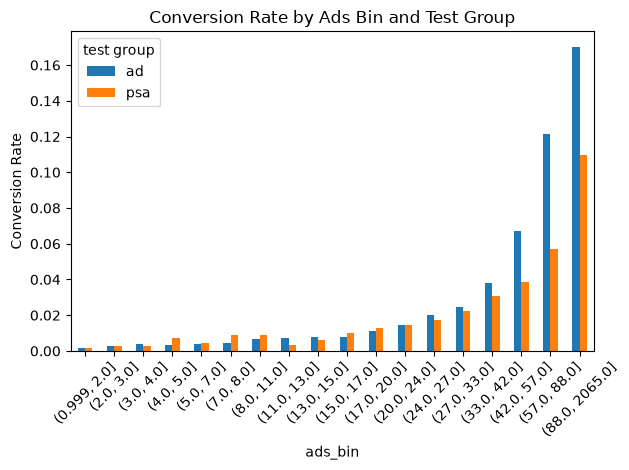

In [44]:
#広告回数との関係：増えれば増えるほどコンバージョン率は差も大きくなる
plt.figure(figsize=(12, 6))
grouped = df.groupby(["ads_bin", "test group"], observed=False)["converted"].mean()
grouped.unstack().plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Ads Bin and Test Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

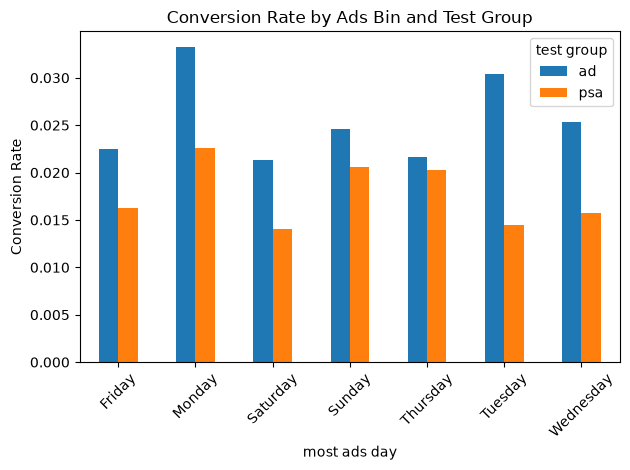

In [46]:
#曜日との関係→火曜日が一番差が大きそう
plt.figure(figsize=(12, 6))
grouped = df.groupby(["most ads day", "test group"], observed=False)["converted"].mean()
grouped.unstack().plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Ads Bin and Test Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

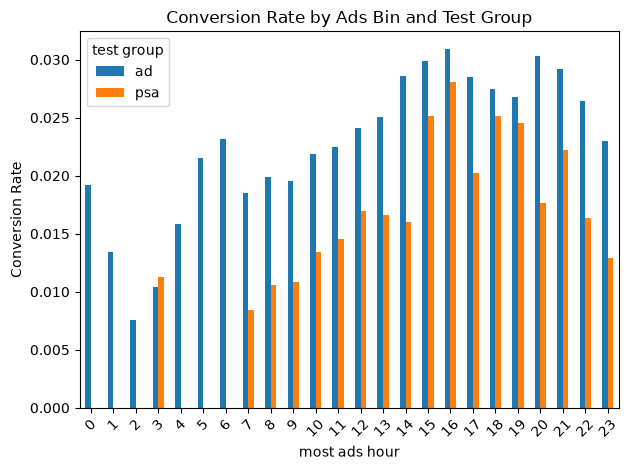

In [47]:
#時間との関係→20時以降~14時あたりまで差が大きそう
plt.figure(figsize=(12, 6))
grouped = df.groupby(["most ads hour", "test group"], observed=False)["converted"].mean()
grouped.unstack().plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Ads Bin and Test Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
#カイ二乗検定
cross_tab = pd.crosstab(df["test group"], df["converted"]
)
print(cross_tab)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420


In [58]:
chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab)

print(f"{chi2:.4f}")
print(f"{p_value:.18f}")


54.0058
0.000000000000199896
